# 04 — Customer Segmentation

K-Means clustering, optimal *k* selection, and segment profiling (Task 2.1).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd
from src.models.pipelines.segmentation_pipeline import fit_segmentation
from src.models.clustering.profiling import profile_cluster_segments, segment_lifts

result = fit_segmentation(k_max=8)
df = result.customer_df
print(f'Optimal k={result.optimal_k}, n={len(df):,}')

Optimal k=6, n=4,750


In [2]:
pd.DataFrame(result.k_evaluation)

,k,inertia,silhouette,calinski_harabasz,min_cluster_pct
0,2,36539.578600,0.152897,912.059331,38.105263
1,3,33522.788215,0.124822,710.560653,29.747368
2,4,31938.734427,0.109780,575.561447,16.694737
3,5,30182.722438,0.109143,525.702851,16.884211
4,6,28769.048782,0.111411,487.757392,13.515789
5,7,27482.656008,0.111424,462.401647,8.884211
6,8,27250.849303,0.093625,405.393938,8.463158


In [3]:
profile_cluster_segments(df, 'segment_id').head(10)

,segment_id,age_mean,age_median,age_count,account_age_days_mean,account_age_days_median,account_age_days_count,financed_amount_mean,financed_amount_median,financed_amount_count,...,risk_stress_score_median,risk_stress_score_count,lead_conversion_speed_mean,lead_conversion_speed_median,lead_conversion_speed_count,installation_delay_days_mean,installation_delay_days_median,installation_delay_days_count,customer_count,pct_of_customers
0,0,39.001555,39.0,643,351.269051,337.0,643,65116.640747,80000.0,643,...,0.000000,643,100.146190,0.0,643,-113.611198,-101.0,643,643,13.5
1,1,38.372274,39.0,642,448.478193,474.5,642,65373.831776,80000.0,642,...,0.600000,642,40.506231,0.0,642,-10.855140,-20.5,642,642,13.5
2,2,38.690574,39.0,976,426.252049,436.0,976,194631.147541,150000.0,976,...,0.600000,976,34.191598,0.0,976,-29.262295,-28.0,976,976,20.5
3,3,38.475348,38.0,791,375.599241,368.0,791,197901.390645,240000.0,791,...,0.000000,791,89.604298,0.0,791,-79.858407,-100.0,791,791,16.7
4,4,38.199797,38.0,986,417.354970,425.0,986,197829.614604,240000.0,986,...,0.494444,986,38.475659,0.0,986,-36.376268,-57.0,986,986,20.8
5,5,38.810393,38.0,712,119.401685,101.0,712,159733.146067,150000.0,712,...,0.600000,712,406.196629,407.0,712,-358.321629,-358.5,712,712,15.0


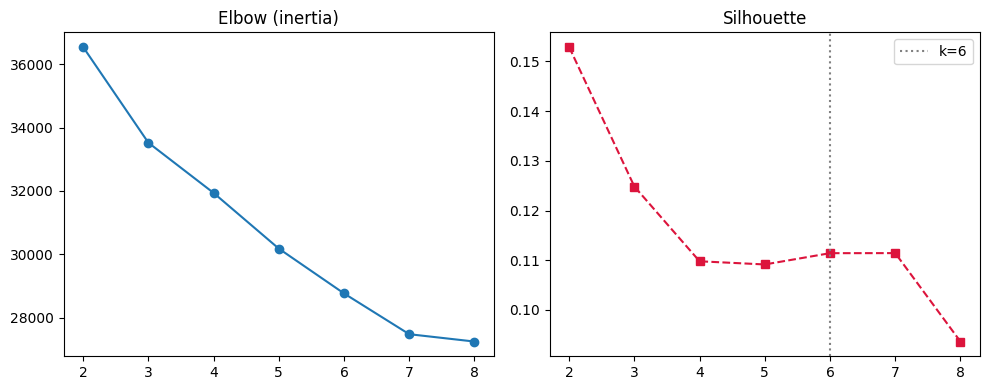

In [4]:
ks = [r['k'] for r in result.k_evaluation]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ks, [r['inertia'] for r in result.k_evaluation], 'o-')
ax[0].set_title('Elbow (inertia)')
ax[1].plot(ks, [r['silhouette'] for r in result.k_evaluation], 's--', color='crimson')
ax[1].axvline(result.optimal_k, color='gray', ls=':', label=f'k={result.optimal_k}')
ax[1].set_title('Silhouette')
ax[1].legend()
plt.tight_layout()
plt.show()